In [1]:
import os
import numpy as np
import scipy
from scipy.signal import butter, filtfilt, find_peaks

# 1. Force PyTorch to fully initialize first to prevent circular |imports
import torch
import torch.fx  
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# 2. Now import Ray and its training submodules safely
import ray
import ray.train.torch
from ray.train import ScalingConfig, Checkpoint
from ray.train.torch import TorchTrainer

In [2]:
ray.init(num_cpus=8, ignore_reinit_error=True)
BASE_PATH = "/expanse/lustre/projects/uci157/ysuh2"
DATA_DIR = "data/stead_version4/"

ds = ray.data.read_parquet(BASE_PATH+"/"+DATA_DIR,shuffle="files").limit(80_000)

def filter_earthquakes(batch):
    return batch[batch["trace_category"] == "earthquake_local"]
    

def preprocess_seismic_batch(batch: dict) -> dict:
    # 1. Directly grab arrays from batch
    filtered_N = batch["waveform_N"]
    filtered_Z = batch["waveform_Z"]
    filtered_E = batch["waveform_E"]

    num_rows = len(filtered_N)
    if num_rows == 0:
        return {"x": [], "y": []}

    # Set known fixed sequence length
    seq_len = 6000

    # 2. Optimized Stack: Vectorized casting directly into float32 matrices
    # (Removes the row-by-row Python loop entirely)
    N_2d = np.array(list(filtered_N), dtype=np.float32)
    Z_2d = np.array(list(filtered_Z), dtype=np.float32)
    E_2d = np.array(list(filtered_E), dtype=np.float32)

    # Now stack into the proper 3D numeric volume: Shape (Batch, 3, Seq_Len)
    X = np.stack([N_2d, Z_2d, E_2d], axis=1)

    # --- FOOLPROOF SCALAR CONVERSION FUNCTION FOR ARRIVALS ---
    def safe_extract_scalar(val):
        try:
            while hasattr(val, "__len__") and not isinstance(val, (str, bytes)):
                if len(val) == 0:
                    return -1.0
                val = val[0]
            return float(val)
        except (ValueError, TypeError):
            return -1.0

    raw_p_unwrapped = [
        safe_extract_scalar(p) for p in batch["p_arrival_sample"]
    ]
    raw_s_unwrapped = [
        safe_extract_scalar(s) for s in batch["s_arrival_sample"]
    ]

    filtered_p = np.asarray(raw_p_unwrapped, dtype=np.float64).astype(np.int64)
    filtered_s = np.asarray(raw_s_unwrapped, dtype=np.float64).astype(np.int64)

    # 3. Apply Bandpass Filter & Normalization
    sampling_rate = 100.0
    nyq = 0.5 * sampling_rate
    b, a = butter(4, [1.0 / nyq, 20.0 / nyq], btype="band")

    X_proc = np.zeros_like(X)
    for idx in range(X.shape[0]):
        for ch in range(3):
            filtered_channel = filtfilt(b, a, X[idx, ch])
            mean = np.mean(filtered_channel)
            std = np.std(filtered_channel)
            X_proc[idx, ch] = (filtered_channel - mean) / (std + 1e-6)

    # 4. Vectorized Label Generation
    sigma = 10.0
    x_ticks = np.arange(seq_len)

    p_diff = x_ticks[None, :] - filtered_p[:, None]
    s_diff = x_ticks[None, :] - filtered_s[:, None]

    Y = np.zeros((X.shape[0], 3, seq_len), dtype=np.float32)

    Y[:, 0, :] = np.exp(-0.5 * (p_diff / sigma) ** 2)
    Y[:, 1, :] = np.exp(-0.5 * (s_diff / sigma) ** 2)

    # Out of timeline bounds validation check
    for idx in range(X.shape[0]):
        if not (0 <= filtered_p[idx] < seq_len):
            Y[idx, 0, :] = 0.0
        if not (0 <= filtered_s[idx] < seq_len):
            Y[idx, 1, :] = 0.0

    Y[:, 2, :] = 1.0 - np.maximum(Y[:, 0, :], Y[:, 1, :])

    y_sum = np.sum(Y, axis=1, keepdims=True)
    Y = Y / np.maximum(y_sum, 1e-8)

    return {"x": X_proc, "y": Y}

# Select, Map, Shuffle, and Split
waveform_ds = ds.select_columns(["waveform_N", "waveform_Z", "waveform_E", "s_arrival_sample", "p_arrival_sample","trace_category"])
waveform_ds = waveform_ds.map_batches(filter_earthquakes, batch_format="pandas")
prepared_ds = waveform_ds.map_batches(preprocess_seismic_batch, batch_format="numpy")
train_ds, val_ds, test_ds = prepared_ds.split_proportionately([0.7, 0.15])


2026-06-01 20:32:12,598	INFO worker.py:1843 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


Metadata Fetch Progress 0:   0%|          | 0.00/140 [00:00<?, ? task/s]

Parquet Files Sample 0:   0%|          | 0.00/8.00 [00:00<?, ? file/s]

2026-06-01 20:32:52,198	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/ray/session_2026-06-01_20-32-08_164773_843239/logs/ray-data
2026-06-01 20:32:52,198	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=80000] -> TaskPoolMapOperator[Project->MapBatches(filter_earthquakes)->MapBatches(preprocess_seismic_batch)] -> AggregateNumRows[AggregateNumRows]


Running 0: 0.00 row [00:00, ? row/s]

...

Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet 1: 0.00 row [00:00, ? row/s]

- limit=80000 2: 0.00 row [00:00, ? row/s]

- Project->MapBatches(filter_earthquakes)->MapBatches(preprocess_seismic_batch) 3: 0.00 row [00:00, ? row/s]

(Project->MapBatches(filter_earthquakes)->MapBatches(preprocess_seismic_batch) pid=844805) Error calculating size for column 'waveform_N': cannot call `vectorize` on size 0 inputs unless `otypes` is set [repeated 2x across cluster]
(Project->MapBatches(filter_earthquakes)->MapBatches(preprocess_seismic_batch) pid=844805) Error calculating size for column 'waveform_Z': cannot call `vectorize` on size 0 inputs unless `otypes` is set [repeated 2x across cluster]
(Project->MapBatches(filter_earthquakes)->MapBatches(preprocess_seismic_batch) pid=844805) Error calculating size for column 'waveform_E': cannot call `vectorize` on size 0 inputs unless `otypes` is set [repeated 2x across cluster]
(Project->MapBatches(filter_earthquakes)->MapBatches(preprocess_seismic_batch) pid=844805) Error calculating size for column 's_arrival_sample': cannot call `vectorize` on size 0 inputs unless `otypes` is set [repeated 2x across cluster]
(Project->MapBatches(filter_earthquakes)->MapBatches(preprocess_se

In [3]:

# ==========================================
# 1. PREPROCESSING & LABEL GENERATION
# ==========================================
def gaussian_label(length, center, sigma=10):
    x = np.arange(length)
    return np.exp(-0.5 * ((x - center) / sigma) ** 2)


def make_phase_labels(length, p_index=None, s_index=None, sigma=10):
    y = np.zeros((3, length), dtype=np.float32)

    if p_index is not None and 0 <= p_index < length:
        y[0] = gaussian_label(length, p_index, sigma)

    if s_index is not None and 0 <= s_index < length:
        y[1] = gaussian_label(length, s_index, sigma)

    phase_max = np.maximum(y[0], y[1])
    y[2] = 1.0 - phase_max

    y_sum = np.sum(y, axis=0, keepdims=True)
    y = y / np.maximum(y_sum, 1e-8)

    return y


def normalize_waveform(x):
    x = x.astype(np.float32)
    for i in range(x.shape[0]):
        mean = np.mean(x[i])
        std = np.std(x[i])
        x[i] = (x[i] - mean) / (std + 1e-6)
    return x


def bandpass_filter(x, sampling_rate, low=1.0, high=20.0, order=4):
    nyq = 0.5 * sampling_rate
    low_norm = low / nyq
    high_norm = high / nyq

    b, a = butter(order, [low_norm, high_norm], btype="band")

    filtered = np.zeros_like(x, dtype=np.float32)
    for i in range(x.shape[0]):
        filtered[i] = filtfilt(b, a, x[i]).astype(np.float32)

    return filtered


# ==========================================
# 2. PYTORCH DATASET
# ==========================================
class PhasePickingDataset(Dataset):
    def __init__(self, records, label_sigma=10, apply_filter=False, sampling_rate=100):
        self.records = records
        self.label_sigma = label_sigma
        self.apply_filter = apply_filter
        self.sampling_rate = sampling_rate

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        x = record["waveform"]  

        if self.apply_filter:
            x = bandpass_filter(x, self.sampling_rate)

        x = normalize_waveform(x)
        length = x.shape[1]
        
        y = make_phase_labels(
            length=length,
            p_index=record.get("p_index"),
            s_index=record.get("s_index"),
            sigma=self.label_sigma,
        )

        return {
            "x": torch.tensor(x, dtype=torch.float32),
            "y": torch.tensor(y, dtype=torch.float32),
        }


# ==========================================
# 3. PHASENET MODEL ARCHITECTURE
# ==========================================
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class PhaseNetLike(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.enc4 = ConvBlock(128, 256)

        self.pool = nn.MaxPool1d(2)
        self.bottleneck = ConvBlock(256, 512)

        self.up4 = nn.ConvTranspose1d(512, 256, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(512, 256)

        self.up3 = nn.ConvTranspose1d(256, 128, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose1d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)

        self.out = nn.Conv1d(32, out_channels, kernel_size=1)

    def crop_or_pad(self, x, target_length):
        current_length = x.shape[-1]
        if current_length == target_length:
            return x
        if current_length > target_length:
            return x[..., :target_length]
        pad_amount = target_length - current_length
        return F.pad(x, (0, pad_amount))

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.crop_or_pad(d4, e4.shape[-1])
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = self.crop_or_pad(d3, e3.shape[-1])
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = self.crop_or_pad(d2, e2.shape[-1])
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = self.crop_or_pad(d1, e1.shape[-1])
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        logits = self.out(d1)
        return F.softmax(logits, dim=1)


# ==========================================
# 4. PARALLEL RAY TRAINING INFRASTRUCTURE
# ==========================================
def soft_cross_entropy(pred, target, eps=1e-8):
    return -(target * torch.log(pred + eps)).sum(dim=1).mean()

def train_func(config):
    lr = config.get("lr", 1e-3)
    batch_size = config.get("batch_size", 16)
    epochs = config.get("epochs", 5)  

    model = PhaseNetLike()
    model = ray.train.torch.prepare_model(model)  
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Grab the distributed shard assigned exclusively to this training worker node
    train_data_shard = ray.train.get_dataset_shard("train")

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        batch_count = 0

        # Efficiently stream batches out of Ray's distributed storage system
        train_loader = train_data_shard.iter_torch_batches(batch_size=batch_size, local_shuffle_buffer_size=250)
        
        for batch in train_loader:
            x = batch["x"] # Automatically converted to torch.Tensor
            y = batch["y"]

            pred = model(x)
            loss = soft_cross_entropy(pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            batch_count += 1

        avg_loss = total_loss / max(batch_count, 1)

        # Handle logging and custom file saving on Rank 0
        if ray.train.get_context().get_world_rank() == 0:
            print(f"Epoch {epoch + 1}: loss = {avg_loss:.5f}")
            
            output_dir = os.environ.get('HOME') + "/ysuh2/model_checkpoints"
            os.makedirs(output_dir, exist_ok=True)
            
            checkpoint_filepath = os.path.join(output_dir, f"phasenet_epoch_{epoch + 1}.pt")
            torch.save(model.module.state_dict(), checkpoint_filepath)
            
            ray.train.report(
                metrics={"loss": avg_loss},
                checkpoint=Checkpoint.from_directory(output_dir)
            )
        else:
            ray.train.report(metrics={"loss": avg_loss})

# ==========================================
# 5. EXECUTION & INFERENCE ENGINE
# ==========================================
def pick_arrivals(probabilities, sampling_rate, window_start_time=0.0):
    p_prob = probabilities[0]
    s_prob = probabilities[1]

    p_index = int(np.argmax(p_prob))
    s_index = int(np.argmax(s_prob))

    p_time = window_start_time + p_index / sampling_rate
    s_time = window_start_time + s_index / sampling_rate

    return p_time, s_time, p_index, s_index




In [4]:
# if __name__ == "__main__":
#     if not ray.is_initialized():
#         ray.init(num_cpus=8, ignore_reinit_error=True)

#     scaling_config = ScalingConfig(num_workers=4, use_gpu=False) # Change to use_gpu=True if nodes have GPUs

#     trainer = TorchTrainer(
#         train_loop_per_worker=train_func,
#         train_loop_config={"lr": 1e-3, "batch_size": 16, "epochs": 5},
#         scaling_config=scaling_config,
#         datasets={"train": train_ds} # Feed the Ray dataset split straight into the trainer!
#     )

#     print("--- Starting Parallel Distributed Ray Training Loop ---")
#     result = trainer.fit()
#     print("--- Training Execution Finished successfully! ---")

#     # --- Run Inference using a real sample from your Test Split ---
#     print("\n--- Running Inference Setup ---")
#     eval_model = PhaseNetLike()
    
#     final_epoch = 5
#     best_checkpoint = result.checkpoint
    
#     if best_checkpoint:
#         with best_checkpoint.as_directory() as checkpoint_dir:
#             local_checkpoint_path = os.path.join(checkpoint_dir, f"phasenet_epoch_{final_epoch}.pt")
#             eval_model.load_state_dict(torch.load(local_checkpoint_path))
#     else:
#         raise RuntimeError("No checkpoint was found in the training result!")

#     eval_model.eval()

#     # Clean Ray native batch extraction
#     test_sample = next(iter(test_ds.iter_batches(batch_size=1, batch_format="numpy")))
#     real_x = test_sample["x"]  # Shape: (1, 3, sequence_length)

#     with torch.no_grad():
#         x_tensor = torch.tensor(real_x, dtype=torch.float32)
#         pred_out = eval_model(x_tensor)[0].cpu().numpy() 

#     # Find predictions using your picking logic
#     p_time, s_time, p_idx, s_idx = pick_arrivals(pred_out, sampling_rate=100.0)

#     print(f"Predicted P Wave Arrival Time: {p_time:.2f}s (Index: {p_idx})")
#     print(f"Predicted S Wave Arrival Time: {s_time:.2f}s (Index: {s_idx})")

#     print("\n--- Running Full Test Dataset Evaluation ---")
    
#     total_test_loss = 0.0
#     test_batch_count = 0

#     test_loader = test_ds.iter_batches(batch_size=64, batch_format="numpy")

#     with torch.no_grad():
#         for batch in test_loader:
#             x_tensor = torch.tensor(batch["x"], dtype=torch.float32)
#             y_tensor = torch.tensor(batch["y"], dtype=torch.float32)

#             pred = eval_model(x_tensor)
#             loss = soft_cross_entropy(pred, y_tensor)
            
#             total_test_loss += loss.item()
#             test_batch_count += 1

#     avg_test_loss = total_test_loss / max(test_batch_count, 1)
#     final_train_loss = result.metrics["loss"]
#     print("--------------------------------------------------")
#     print(f"Final Training Loss: {final_train_loss:.5f}")
#     print(f"Final Average Test Loss: {avg_test_loss:.5f}")
#     print(f"Evaluated on {test_batch_count * 64} total samples.")
#     print("--------------------------------------------------")

Model successfully loaded from: /home/ysuh2/ysuh2/model_checkpoints/phasenet_epoch_5.pt
Extracting picks and calculating timing residuals...

             RESIDUAL ANALYSIS REPORT
P-Wave Picks Evaluated : 16350
  - Mean Error (Bias)  : 0.1772 seconds
  - Median Error       : 0.0100 seconds
  - Std Dev (Spread)   : 2.0760 seconds
  - Mean Absolute Error: 0.2153 seconds
--------------------------------------------------
S-Wave Picks Evaluated : 16350
  - Mean Error (Bias)  : 0.0619 seconds
  - Median Error       : 0.0100 seconds
  - Std Dev (Spread)   : 0.7168 seconds
  - Mean Absolute Error: 0.1280 seconds


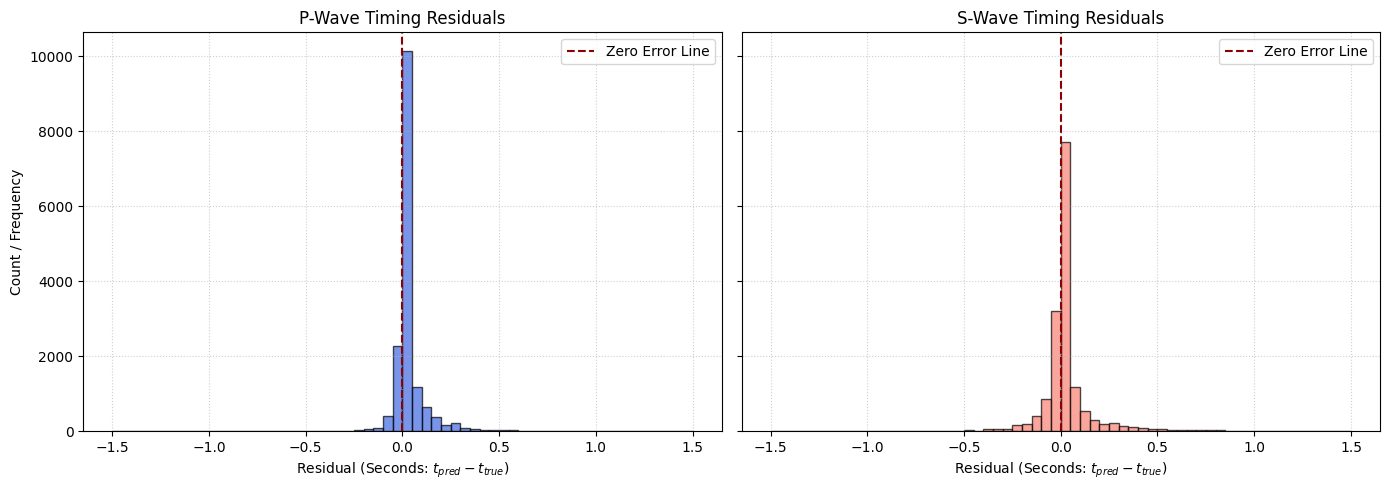

In [5]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PATH & DEVICE CONFIGURATION
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = os.path.expanduser("~/ysuh2/model_checkpoints/phasenet_epoch_5.pt")
sampling_rate = 100.0  

# Initialize and load model weights
model = PhaseNetLike()
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"Model successfully loaded from: {checkpoint_path}")
else:
    raise FileNotFoundError(f"No checkpoint file found at {checkpoint_path}")

# ==========================================
# 2. RESIDUAL COLLECTION LOOP (FIXED FOR RAY)
# ==========================================
p_residuals = []
s_residuals = []

target_dataset = test_ds  

print("Extracting picks and calculating timing residuals...")
with torch.no_grad():
    for batch in target_dataset.iter_batches(batch_size=64, batch_format="numpy"):
        # Model Inference
        x_tensor = torch.tensor(batch["x"], dtype=torch.float32).to(device)
        preds = model(x_tensor).cpu().numpy()  # Shape: (Batch, 3, Sequence_Length)
        trues = batch["y"]                     # Shape: (Batch, 3, Sequence_Length)
        
        # Determine total samples in this batch explicitly
        num_samples = trues.shape[0]
        
        for i in range(num_samples):
            # Extract across the 3 channel distributions cleanly: [channel, sequence]
            true_p_curve = trues[i, 0, :]
            true_s_curve = trues[i, 1, :]
            
            pred_p_curve = preds[i, 0, :]
            pred_s_curve = preds[i, 1, :]
            
            # Check if a true arrival Gaussian was generated for this sample
            if np.max(true_p_curve) > 0.01: 
                true_p_idx = np.argmax(true_p_curve)
                pred_p_idx = np.argmax(pred_p_curve)
                p_residuals.append((pred_p_idx - true_p_idx) / sampling_rate)
                
            if np.max(true_s_curve) > 0.01:
                true_s_idx = np.argmax(true_s_curve)
                pred_s_idx = np.argmax(pred_s_curve)
                s_residuals.append((pred_s_idx - true_s_idx) / sampling_rate)

p_residuals = np.array(p_residuals)
s_residuals = np.array(s_residuals)

# ==========================================
# 3. STATISTICAL METRICS REPORT
# ==========================================
print("\n" + "="*50)
print("             RESIDUAL ANALYSIS REPORT")
print("="*50)
if len(p_residuals) > 0:
    print(f"P-Wave Picks Evaluated : {len(p_residuals)}")
    print(f"  - Mean Error (Bias)  : {np.mean(p_residuals):.4f} seconds")
    print(f"  - Median Error       : {np.median(p_residuals):.4f} seconds")
    print(f"  - Std Dev (Spread)   : {np.std(p_residuals):.4f} seconds")
    print(f"  - Mean Absolute Error: {np.mean(np.abs(p_residuals)):.4f} seconds")
else:
    print("No valid P-wave picks found. Check if ground truth labels exist in 'test_ds'.")

print("-" * 50)
if len(s_residuals) > 0:
    print(f"S-Wave Picks Evaluated : {len(s_residuals)}")
    print(f"  - Mean Error (Bias)  : {np.mean(s_residuals):.4f} seconds")
    print(f"  - Median Error       : {np.median(s_residuals):.4f} seconds")
    print(f"  - Std Dev (Spread)   : {np.std(s_residuals):.4f} seconds")
    print(f"  - Mean Absolute Error: {np.mean(np.abs(s_residuals)):.4f} seconds")
else:
    print("No valid S-wave picks found. Check if ground truth labels exist in 'test_ds'.")
print("="*50)

# ==========================================
# 4. PLOT HISTOGRAMS
# ==========================================
if len(p_residuals) > 0 or len(s_residuals) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    bin_range = (-1.5, 1.5) 

    # P-wave Histogram
    if len(p_residuals) > 0:
        axes[0].hist(p_residuals, bins=60, range=bin_range, color='royalblue', edgecolor='black', alpha=0.7)
        axes[0].axvline(0, color='darkred', linestyle='--', linewidth=1.5, label='Zero Error Line')
        axes[0].set_title("P-Wave Timing Residuals", fontsize=12)
        axes[0].set_xlabel("Residual (Seconds: $t_{pred} - t_{true}$)", fontsize=10)
        axes[0].set_ylabel("Count / Frequency", fontsize=10)
        axes[0].grid(True, linestyle=':', alpha=0.6)
        axes[0].legend()

    # S-wave Histogram
    if len(s_residuals) > 0:
        axes[1].hist(s_residuals, bins=60, range=bin_range, color='salmon', edgecolor='black', alpha=0.7)
        axes[1].axvline(0, color='darkred', linestyle='--', linewidth=1.5, label='Zero Error Line')
        axes[1].set_title("S-Wave Timing Residuals", fontsize=12)
        axes[1].set_xlabel("Residual (Seconds: $t_{pred} - t_{true}$)", fontsize=10)
        axes[1].grid(True, linestyle=':', alpha=0.6)
        axes[1].legend()

    plt.tight_layout()
    plt.show()